In [3]:
# Importing essential libraries

import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np

In [4]:
import sqlite3

# connect to SQLite database file

conn = sqlite3.connect("noshow.db")

In [5]:
# confirming table name before loading actual data

query = "SELECT name FROM sqlite_master WHERE type='table';"
tables = pd.read_sql_query(query, conn)

tables

,name
0,noshow


In [6]:
# loading dataset from SQLite into pandas

df = pd.read_sql_query("SELECT * FROM noshow", conn)
df.head()

,booking_id,no_show,branch,booking_month,arrival_month,arrival_day,checkout_month,checkout_day,country,first_time,room,price,platform,num_adults,num_children
0,94113,0.0,Changi,November,June,25.0,June,27.0,Singapore,Yes,Single,SGD$ 492.98,Website,1,0.0
1,86543,0.0,Orchard,August,November,28.0,November,29.0,Indonesia,Yes,King,SGD$ 1351.22,Website,2,0.0
2,75928,0.0,Changi,March,February,7.0,February,11.0,India,Yes,Single,None,Agent,1,0.0
3,66947,1.0,Orchard,September,October,1.0,October,3.0,China,Yes,Single,SGD$ 666.04,Website,1,0.0
4,106390,0.0,Orchard,March,June,20.0,June,24.0,Australia,Yes,Queen,USD$ 665.37,Website,1,0.0


In [7]:
# checking dataset size

df.shape

(119391, 15)

There are 119,391 rows and 15 columns

In [8]:
# Checking column names and data types. To identify whether a column is integer, string etc, also for missing values and Nulls

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119391 entries, 0 to 119390
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   booking_id      119391 non-null  int64  
 1   no_show         119390 non-null  float64
 2   branch          119390 non-null  object 
 3   booking_month   119390 non-null  object 
 4   arrival_month   119390 non-null  object 
 5   arrival_day     119390 non-null  float64
 6   checkout_month  119390 non-null  object 
 7   checkout_day    119390 non-null  float64
 8   country         119390 non-null  object 
 9   first_time      119390 non-null  object 
 10  room            97778 non-null   object 
 11  price           94509 non-null   object 
 12  platform        119390 non-null  object 
 13  num_adults      119390 non-null  object 
 14  num_children    119390 non-null  float64
dtypes: float64(4), int64(1), object(10)
memory usage: 13.7+ MB


In [9]:
# perform statistical summary

df.describe()

,booking_id,no_show,arrival_day,checkout_day,num_children
count,119391.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,59695.000000,0.370416,15.798241,14.250507,0.871229
std,34465.357332,0.482918,8.780829,11.063697,0.779796
min,0.000000,0.000000,1.000000,-31.000000,0.000000
25%,29847.500000,0.000000,8.000000,7.000000,0.000000
50%,59695.000000,0.000000,16.000000,15.000000,1.000000
75%,89542.500000,1.000000,23.000000,23.000000,1.000000
max,119390.000000,1.000000,31.000000,31.000000,3.000000


In [10]:
# checking missing values

df.isnull().sum()

booking_id            0
no_show               1
branch                1
booking_month         1
arrival_month         1
arrival_day           1
checkout_month        1
checkout_day          1
country               1
first_time            1
room              21613
price             24882
platform              1
num_adults            1
num_children          1
dtype: int64

In [11]:
# inspect all columns clearly

df.columns

Index(['booking_id', 'no_show', 'branch', 'booking_month', 'arrival_month',
       'arrival_day', 'checkout_month', 'checkout_day', 'country',
       'first_time', 'room', 'price', 'platform', 'num_adults',
       'num_children'],
      dtype='object')

In [12]:
# remove that corrupted/empty row with the booking id - 115536

df = df[df['booking_id'] != 115536]

In [13]:
# checking dataset again

df.shape

(119390, 15)

In [14]:
# performing missing value analysis

missing = df.isnull().sum().sort_values(ascending=False)
missing

price             24881
room              21612
booking_id            0
no_show               0
branch                0
booking_month         0
arrival_month         0
arrival_day           0
checkout_month        0
checkout_day          0
country               0
first_time            0
platform              0
num_adults            0
num_children          0
dtype: int64

In [15]:
# fixing data types

# converting the following columns to integer

columns_to_convert = ['no_show', 'arrival_day', 'checkout_day', 'num_children']

df[columns_to_convert] = df[columns_to_convert].astype(int)

In [16]:
# confirming columns has been converted to integer

df.head(20)

,booking_id,no_show,branch,booking_month,arrival_month,arrival_day,checkout_month,checkout_day,country,first_time,room,price,platform,num_adults,num_children
0,94113,0,Changi,November,June,25,June,27,Singapore,Yes,Single,SGD$ 492.98,Website,1,0
1,86543,0,Orchard,August,November,28,November,29,Indonesia,Yes,King,SGD$ 1351.22,Website,2,0
2,75928,0,Changi,March,February,7,February,11,India,Yes,Single,None,Agent,1,0
3,66947,1,Orchard,September,October,1,October,3,China,Yes,Single,SGD$ 666.04,Website,1,0
4,106390,0,Orchard,March,June,20,June,24,Australia,Yes,Queen,USD$ 665.37,Website,1,0
5,55212,0,Orchard,November,September,12,September,13,Indonesia,Yes,None,SGD$ 1499.61,Website,2,2
6,42322,0,Orchard,November,October,15,October,16,Australia,Yes,King,SGD$ 1375.44,Website,1,1
7,23137,0,Changi,July,November,18,November,19,India,Yes,King,None,Email,2,1
8,109456,1,Changi,January,June,27,June,28,China,Yes,None,USD$ 658.75,Email,2,1
9,31117,0,Orchard,October,March,22,March,24,China,Yes,None,USD$ 962.75,Website,1,1


In [17]:
# to find out which rows where the values are not valid numbers

invalid_rows = df[pd.to_numeric(df['num_adults'], errors='coerce').isna()]
print(invalid_rows[['booking_id', 'num_adults']])

        booking_id num_adults
11          108345        one
17           85014        one
18           28009        two
25           17827        one
40          109700        two
...            ...        ...
119316       11963        two
119324       39243        one
119336       91438        one
119368         700        two
119370       53658        one

[11402 rows x 2 columns]


In [18]:
# inspecting all unique entries before converting

print(df['num_adults'].unique())

['1' '2' 'one' 'two']


In [19]:
# map text numbers to integers

word_to_num = {

    'one' : 1,
    'two' : 2
}

# clean text and convert

df['num_adults'] = (
    df['num_adults']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace(word_to_num)
)

In [20]:
# convert to integer

df['num_adults'] = pd.to_numeric(df['num_adults'], errors='raise').astype(int)

In [21]:
df.head(50)

,booking_id,no_show,branch,booking_month,arrival_month,arrival_day,checkout_month,checkout_day,country,first_time,room,price,platform,num_adults,num_children
0,94113,0,Changi,November,June,25,June,27,Singapore,Yes,Single,SGD$ 492.98,Website,1,0
1,86543,0,Orchard,August,November,28,November,29,Indonesia,Yes,King,SGD$ 1351.22,Website,2,0
2,75928,0,Changi,March,February,7,February,11,India,Yes,Single,None,Agent,1,0
3,66947,1,Orchard,September,October,1,October,3,China,Yes,Single,SGD$ 666.04,Website,1,0
4,106390,0,Orchard,March,June,20,June,24,Australia,Yes,Queen,USD$ 665.37,Website,1,0
5,55212,0,Orchard,November,September,12,September,13,Indonesia,Yes,None,SGD$ 1499.61,Website,2,2
6,42322,0,Orchard,November,October,15,October,16,Australia,Yes,King,SGD$ 1375.44,Website,1,1
7,23137,0,Changi,July,November,18,November,19,India,Yes,King,None,Email,2,1
8,109456,1,Changi,January,June,27,June,28,China,Yes,None,USD$ 658.75,Email,2,1
9,31117,0,Orchard,October,March,22,March,24,China,Yes,None,USD$ 962.75,Website,1,1


Data Wrangling

A - Creating length_of_stay without using year

In [22]:
# step A1 - mapping month names to month numbers

month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}

df['arrival_month_num'] = df['arrival_month'].map(month_map)
df['checkout_month_num'] = df['checkout_month'].map(month_map)

In [23]:
# step A2 - calculate stay length

days_in_month = {
    1: 31, 2: 28, 3: 31, 4: 30,
    5: 31, 6: 30, 7: 31, 8: 31,
    9: 30, 10: 31, 11: 30, 12: 31
}

def calc_stay(row):
    arr_m = row['arrival_month_num']
    out_m = row['checkout_month_num']
    arr_d = row['arrival_day']
    out_d = row['checkout_day']
    
    # same month

    if arr_m == out_m:
        return max(out_d - arr_d, 1)
    
    # next month OR Dec -> Jan
    
    elif (out_m == arr_m + 1) or (arr_m == 12 and out_m == 1):
        return (days_in_month[arr_m] - arr_d) + out_d
    
    # fallback for usual cases
    
    else :
        return abs(out_d - arr_d)

df['length_of_stay'] = df.apply(calc_stay, axis=1)

B - Impute missing room type using price per night, stay length and room based on existing room price bands

In [24]:
# step B1 - spliting currency and price

price_clean = df['price'].astype(str).str.strip()

df['currency'] = price_clean.str.extract(r'^(USD|SGD)\$', expand=False)

df['price_value'] = pd.to_numeric(
    price_clean.str.extract(r'(\d+\.?\d*)', expand=False),
    errors='coerce'
)

In [25]:
# step B2 - converting all prices to SGD

usd_to_sgd = 1.2738

df['price_sgd'] = df['price_value']
df.loc[df['currency'] == 'USD', 'price_sgd'] *= usd_to_sgd
df['price_sgd'] = df['price_sgd'].round(2)

In [26]:
# step B3 - estimate nightly price

df['nightly_rate'] = df['price_sgd'] / df['length_of_stay']
df['nightly_rate'] = pd.to_numeric(df['nightly_rate'], errors ='coerce').abs()
df['nightly_rate'] = df['nightly_rate'].round(2)

In [27]:
# step B4 - infer missing room using closest median room rate because it is much more accurate when we use actual price + stay duration

# a) replace 'None' room with NaN

df['room'] = df['room'].replace(['None', 'none', 'NONE'], pd.NA)

In [28]:
# b) median nightly rate by room

room_reference = df.groupby('room')['nightly_rate'].median()

def infer_room(rate):
    return (room_reference - rate).abs().idxmin()

missing_room_mask = df['room'].isna()

df.loc[missing_room_mask, 'room'] = df.loc[
    missing_room_mask, 'nightly_rate'
].apply(infer_room)

In [29]:
# rounding off to 2 decimal places

df['price_sgd'] = df['price_sgd'].fillna(
    (df['nightly_rate'] * df['length_of_stay']).round(2)
)

C - Calculate room-reference expected price

In [30]:
# create a clean benchmark price

room_daily_ref = df.groupby('room')['nightly_rate'].median()

df['expected_price_sgd'] = (
    df['room'].map(room_daily_ref) *
    df['length_of_stay']
).round(2)

In [31]:
# Filling missing price_sgd, price_value and currency

# Fill missing SGD prices from expected price

df['price_sgd'] = df['price_sgd'].fillna(df['expected_price_sgd'])

# Fill missing raw price value using the same imputed SGD amount

df['price_value'] = df['price_value'].fillna(df['expected_price_sgd'])

# Fill missing currency as SGD

df['currency'] = df['currency'].fillna('SGD')

# Recalculate nightly rate for the filled rows

df['nightly_rate'] = (
    df['price_sgd'] / df['length_of_stay']
).round(2)

In [32]:
# quick validation

print(df[['booking_id', 'currency', 'room','price_sgd', 'nightly_rate']].head(50))
print(df[['price_sgd', 'currency']].isna().sum())

    booking_id currency             room  price_sgd  nightly_rate
0        94113      SGD           Single     492.98        246.49
1        86543      SGD             King    1351.22       1351.22
2        75928      SGD           Single    1265.84        316.46
3        66947      SGD           Single     666.04        333.02
4       106390      USD            Queen     847.55        211.89
5        55212      SGD  President Suite    1499.61       1499.61
6        42322      SGD             King    1375.44       1375.44
7        23137      SGD             King     657.60        657.60
8       109456      USD  President Suite     839.12        839.12
9        31117      USD             King    1226.35        613.17
10       65862      SGD             King    1478.01       1478.01
11      108345      SGD             King     867.99        867.99
12       81453      SGD             King     869.72        869.72
13       88243      USD           Single     747.76        373.88
14      11

PHASE 1 — Professional EDA + business insights

We start by understanding the business problem:

What drives no-show behavior?

Suggested storyline:

Target distribution
Categorical analysis
branch
platform
first-time vs returning
room
country
Numerical analysis
price
nightly rate
stay length
adults / children
Business insights

In [33]:
# step 1 - No-show distribution by count and percentage

print(df['no_show'].value_counts())
print(df['no_show'].value_counts(normalize=True) * 100)

0    75166
1    44224
Name: no_show, dtype: int64
0    62.958372
1    37.041628
Name: no_show, dtype: float64


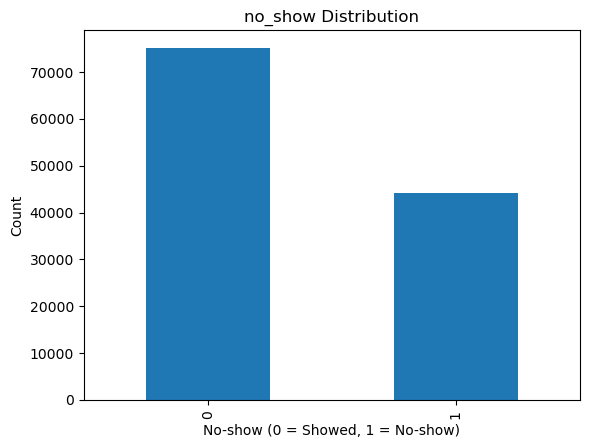

In [34]:
# chart

import matplotlib.pyplot as plt

df['no_show'].value_counts().plot(kind='bar')
plt.title('no_show Distribution')
plt.xlabel('No-show (0 = Showed, 1 = No-show)')
plt.ylabel('Count')
plt.show()

This exploratory data analysis examines hotel booking no-show patterns across two branches (Changi and Orchard), multiple booking platforms, and guest types. The dataset contains approximately 110,000 bookings. The analysis reveals a 37% overall no-show rate, significantly higher than the industry average of 20%, indicating a serious revenue leakage problem requiring immediate attention.     

A quick business impact estimate:

110,000 × 37% ≈ 40,700

That means approximately 40,700 no-show bookings.

Even with a conservative average room value assumption:

SGD 120 per booking → ~SGD 4.88M leakage

SGD 150 per booking → ~SGD 6.11M leakage

SGD 200 per booking → ~SGD 8.14M leakage

In [35]:
# step 2 - No-show by branch (extremely valueable for operations)

branch_noshow = pd.crosstab(
    df['branch'],
    df['no_show'],
    normalize = 'index'
) * 100

print(branch_noshow)

no_show          0          1
branch                       
Changi   58.273037  41.726963
Orchard  72.236645  27.763355


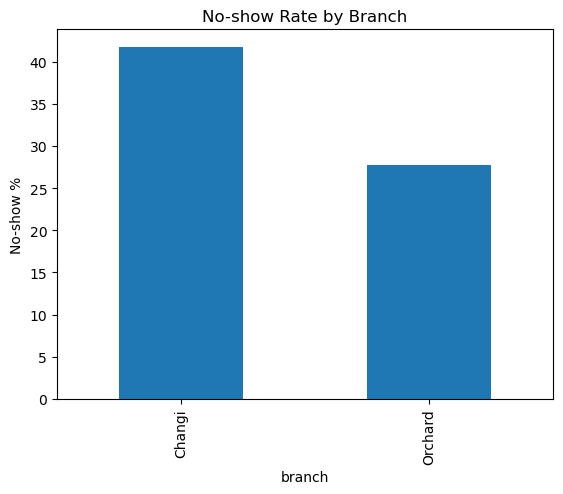

In [36]:
# chart

branch_noshow[1].plot(kind='bar')
plt.title('No-show Rate by Branch')
plt.ylabel('No-show %')
plt.show()

Surprisingly, Changi branch has higher No-show percentage compare to Orchard  even when it is nearer to the Changi Airport. Reason may due to travelers changing their initial plans last-minute and wish relocate to city as it's better access to tourist attractions while staying in changi makes it more difficult to travel to those hot spots. Other possible following reasons;

a) flight delays / cancellations
b) change in itinerary
c) transit passengers
d) late-night booking abandonment
e) last-minute relocation to city hotels
f) business travelers changing schedule

In [37]:
# step 3 - No-show by platform (very important commerically)

platform_noshow = pd.crosstab(
    df['platform'],
    df['no_show'],
    normalize = 'index'
) * 100

print(platform_noshow)

no_show           0          1
platform                      
Agent     63.013573  36.986427
Email     62.542934  37.457066
Phone     63.738093  36.261907
Website   63.030571  36.969429


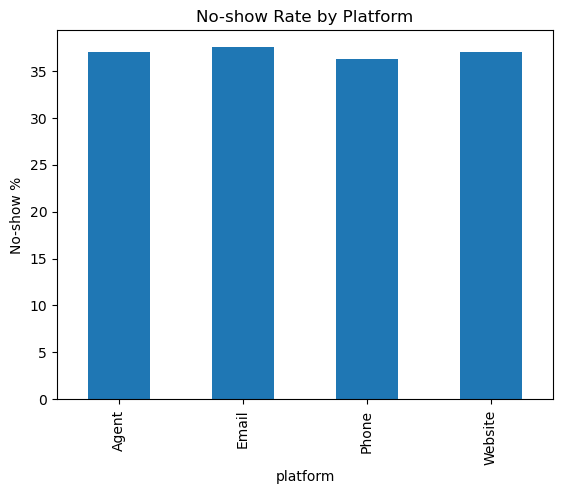

In [38]:
# chart 

platform_noshow[1].plot(kind='bar')
plt.title('No-show Rate by Platform')
plt.ylabel('No-show %')
plt.show()

Bookings through email has the highest risk of 37.5% no show rate. No-show risk is strongly influenced by booking channel commitment level.

Recommended actions

Email bookings

a) deposit requirement
b) reminder emails / WhatsApp confirmation
c) 24-hour reconfirmation workflow

Phone bookings

a) use as “gold standard low-risk channel”

In [39]:
# step 4 - first timer vs returner

first_noshow = pd.crosstab(
    df['first_time'],
    df['no_show'],
    normalize = 'index'
) * 100

print(first_noshow)

no_show             0          1
first_time                      
No          85.511811  14.488189
Yes         62.214916  37.785084


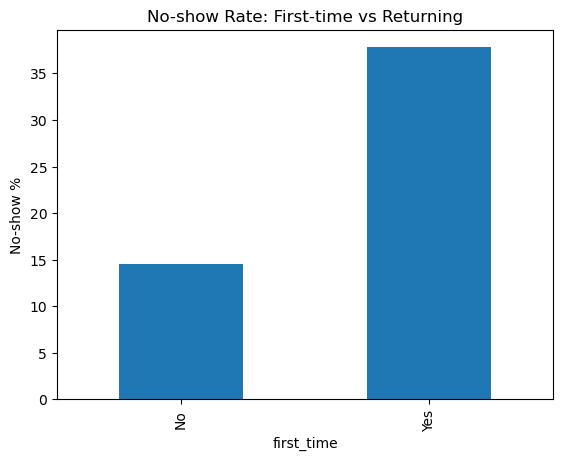

In [40]:
# chart

first_noshow[1].plot(kind='bar')
plt.title('No-show Rate: First-time vs Returning')
plt.ylabel('No-show %')
plt.show()

We noticed the no-show rate for first-time guests compare to the regulars is about 2.6x. This may reflect that first-time guests likely to have higher tendency of cancellations due to uncertainties

In [41]:
# step 5 - Price vs no-show

df.groupby('no_show')['price_sgd'].mean()

no_show
0    972.481404
1    966.698285
Name: price_sgd, dtype: float64

<Figure size 600x400 with 0 Axes>

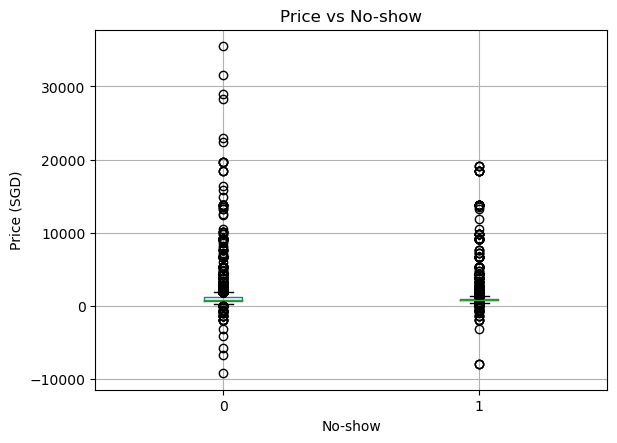

In [42]:
# chart

plt.figure(figsize=(6,4))
df.boxplot(column='price_sgd', by='no_show')
plt.title('Price vs No-show')
plt.suptitle('')
plt.xlabel('No-show')
plt.ylabel('Price (SGD)')
plt.show()


High-price bookings may not necessary for no-show scenario. This variable is a  weak predictor of No-show

In [43]:
# step 6 - stay length vs no-show

df.groupby('no_show')['length_of_stay'].mean()

no_show
0    2.049584
1    2.132032
Name: length_of_stay, dtype: float64

<Figure size 600x400 with 0 Axes>

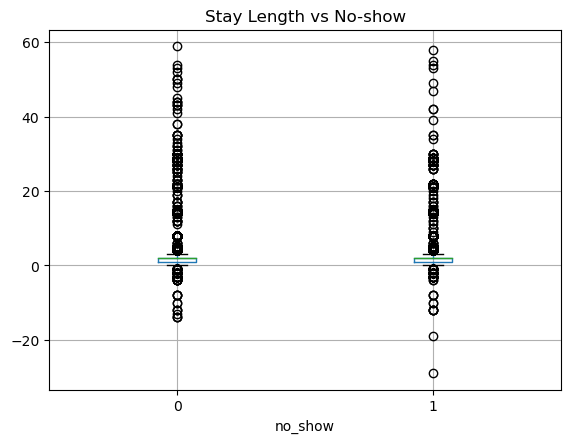

In [44]:
# chart

plt.figure(figsize=(6,4))
df.boxplot(column='length_of_stay', by='no_show')
plt.title('Stay Length vs No-show')
plt.suptitle('')
plt.show()

Longer stays may imply better intended planning while other reason could be due to unforeseen circumstances leading to an extended stay. This variable is also a weak predictor of No-show

Professional feature engineering for ML

Business framing:

“Predict probability of no-show to optimise overbooking, pricing, and customer targeting.”

In [45]:
# listing feature for selection

df.columns

Index(['booking_id', 'no_show', 'branch', 'booking_month', 'arrival_month',
       'arrival_day', 'checkout_month', 'checkout_day', 'country',
       'first_time', 'room', 'price', 'platform', 'num_adults', 'num_children',
       'arrival_month_num', 'checkout_month_num', 'length_of_stay', 'currency',
       'price_value', 'price_sgd', 'nightly_rate', 'expected_price_sgd'],
      dtype='object')

Select useful features: strong candidates are as follows;

branch
platform
first_time
room
country (may need grouping later)
num_adults
num_children
length_of_stay
price_sgd
nightly_rate
expected_price_sgd
arrival_month_num

In [46]:
# Step 1 - Feature selection. Dropping these first...

df_model = df.drop(columns=[
    'booking_id',       # ID (no predictive value)
    'price',            # raw string version
])

In [47]:
# Step 2 - Handle categorical variables (KNN needs numeric input)

df_model = pd.get_dummies(df_model, drop_first=True)

In [48]:
# Step 3 - Define X and Y 

X = df_model.drop('no_show', axis=1)
y = df_model['no_show']

In [49]:
# Step 4 - Train/Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # important for class balance
)

In [50]:
# FIX (Clean before scaling)

# a1) Check problematic values 

import numpy as np

np.isinf(X_train).sum().sum()

62

In [51]:
# a2) Check problematic values

X_train.isnull().sum().sort_values(ascending=False)

arrival_month_num         1283
nightly_rate                16
arrival_month_OcTober        0
arrival_month_NovembEr       0
arrival_month_NovembeR       0
                          ... 
arrival_month_DecembeR       0
arrival_month_DecembEr       0
arrival_month_DecemBer       0
arrival_month_DeceMber       0
currency_USD                 0
Length: 135, dtype: int64

In [52]:
# b) Replace Infinity values

X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

In [53]:
# c) Handle missing values (critical). For KNN, simplest approach...(use train median, not test - correct ML practice)

X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

In [54]:
# c) Fixing root cause (if 'length of stay' = 0 then boom = infinity. Therefore, fixing it properly)

df_model = df_model[df_model['length_of_stay'] > 0]

In [55]:
# Step 5 - Scaling (critical for KNN. KNN is distance-based, scaling is mandatory)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [56]:
# Step 6 - Train KNN model

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [57]:
# Suppressing warnings 

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [58]:
# Step 7 - Predictions

y_pred = knn.predict(X_test_scaled)

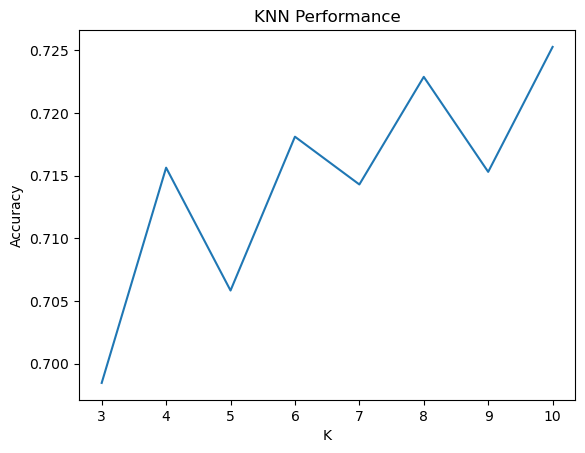

In [59]:
# Step 8 - Improve modelling - KNN depends heavily on K

import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

scores = []

for k in range(3, 11):
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    scores.append(accuracy_score(y_test, y_pred))

plt.plot(range(3,11), scores)
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("KNN Performance")
plt.show()

In [60]:
# Step 9 - Evaluation - Confusion Matrix and Classification Report

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight='balanced',   # 🔥 key change
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[12204  2829]
 [ 3429  5416]]
              precision    recall  f1-score   support

           0       0.78      0.81      0.80     15033
           1       0.66      0.61      0.63      8845

    accuracy                           0.74     23878
   macro avg       0.72      0.71      0.71     23878
weighted avg       0.73      0.74      0.74     23878



# Business Interpretation: 

a) Key metrics:

Precision (no-show) → how accurate when predicting no-show
Recall (no-show) → how many actual no-shows we catch

b) High recall → good for overbooking strategy
   High precision → good for targeted interventions (e.g. reminders, deposits)
   
   Interpretation:

12204 → correctly predicted show
5416 → correctly predicted no-show
2829 → predicted no-show but actually showed (False positives increased-more “false alarms”)
3429 → predicted show but actually no-show (missed no-show)


Accuracy: 0.74
Recall (no-show): 0.61
Missed no-shows : 3429
Precision (no-show): 0.66

“By introducing class weighting, I improved no-show recall from 49% to 61%, significantly increasing detection of high-risk bookings. While this introduced more false positives, the trade-off is acceptable as it enables proactive interventions and reduces potential revenue loss.”

ROC Curve (model performance visual)

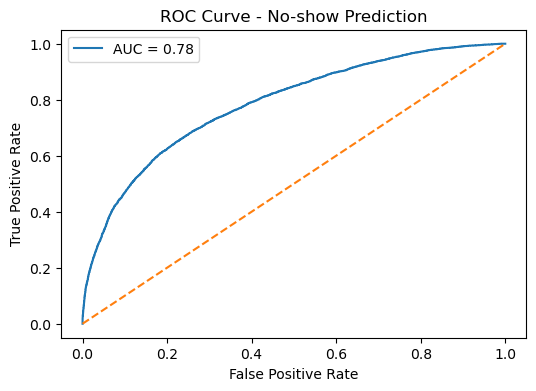

In [61]:
# Model showing show vs no-show

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# predicted probabilities
y_prob = rf.predict_proba(X_test)[:, 1]

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - No-show Prediction")
plt.legend()
plt.show()

The ROC curve shows the model’s ability to distinguish between no-show and show customers. The AUC score indicates overall classification strength. The above reading is 0.78, very much closer to "Strong"

👉 AUC guide:

0.5 → useless
0.7 → decent
0.8+ → strong

In [62]:
# Feature Importance - "What actually drives no-shows?"

import pandas as pd

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(10)

country_China         0.307708
branch_Orchard        0.058350
country_India         0.055626
country_Japan         0.051321
nightly_rate          0.049431
country_Indonesia     0.048549
price_sgd             0.042344
price_value           0.035828
first_time_Yes        0.033735
expected_price_sgd    0.033345
dtype: float64

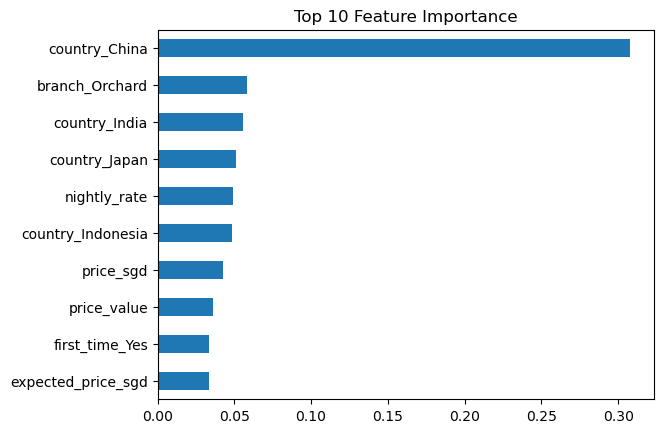

In [63]:
# Top 10 feature importance of no-shows

feature_importance.head(10).plot(kind='barh')
plt.title("Top 10 Feature Importance")
plt.gca().invert_yaxis()
plt.show()

The most important drivers of no-show include pricing, booking platform, and customer type, which aligns with earlier EDA findings.